In [42]:
import yaml
import glob
import os
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.manifold import TSNE

import random
from rdkit.Chem import Draw

from rdkit import Chem, DataStructs, rdBase
from rdkit.Chem import Draw, AllChem
rdBase.DisableLog('rdApp.*')  # RDKitのエラーログを無効化
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.ML.Cluster import Butina

from tdc import Evaluator as tdc_Evaluator

from mol_data import Mol_Data
from evaluator import Evaluator
from evaluator import population_similarity

In [43]:
class Island:

    smi2score = {}

    def __init__(self, path, task):
        self.evaluator = Evaluator(task)
        self.populations = []
        self.num_generation = 0

        self.load(path)

    def load(self,path):
        path = os.path.join(path,'population')
        # 指定されたディレクトリ内で'population_'で始まるすべてのYAMLファイルを検索します。
        yaml_files = glob.glob(os.path.join(path, 'population_*.yaml'))
        if yaml_files == []:
            print("No result files found in {}".format(path))
            return
        self.num_generation = len(yaml_files)

        def get_generation_number(filepath):
            """
            ファイル名から世代番号を抽出するためのヘルパー関数です。
            """
            filename = os.path.basename(filepath)
            # ファイル名の形式は 'population_{世代番号}G.yaml' を想定しています。
            try:
                # 世代番号の文字列を抽出し、整数に変換します。
                gen_str = filename.split('_')[1].replace('G.yaml', '')
                return int(gen_str)
            except (IndexError, ValueError):
                # ファイル名が期待される形式でない場合は-1を返します。
                return -1

        # 世代番号に基づいてYAMLファイルをソートし、時系列順に処理できるようにします。
        yaml_files.sort(key=get_generation_number)

        # ソートされたファイルリストをループ処理し、YAMLデータを読み込んで結果リストに追加します。
        print("Loading results ...")
        for yaml_file in tqdm(yaml_files):
            with open(yaml_file, 'r', encoding='utf-8') as f:
                datas = yaml.safe_load(f)
                population = []
                for data in datas.values():
                    
                    if data["smi"] not in Island.smi2score:
                        Island.smi2score[data["smi"]] = self.evaluator.score(data["smi"])

                    if "inter_smi" in data:
                        population.append(Mol_Data(
                            Chem.MolFromSmiles(data["smi"]),
                            data["smi"],
                            Island.smi2score[data["smi"]],
                            data["parent1_smi"],
                            data["parent2_smi"],
                            data["inter_smi"]))
                    if "inter_smi" not in data:
                        population.append(Mol_Data(
                            Chem.MolFromSmiles(data["smi"]),
                            data["smi"],
                            Island.smi2score[data["smi"]],
                            data["parent1_smi"],
                            data["parent2_smi"]))

                self.populations.append(population)

        print("Loading finished")

In [44]:
class visualizer:
    def __init__(self, islands):
        self.islands = islands
        self.diversity_evaluator = tdc_Evaluator(name="Diversity")

    def population_score(self,island):
        scores = []
        for population in island.populations:
            scores.append(np.mean([mlc.score for mlc in population]))
        return scores

    def plot_scoore_shift(self):
        avg_scores_dict = {name: self.population_score(island) for name, island in self.islands.items()}

        # Plot the avg_scores
        plt.figure(figsize=(10, 6))
        for name, scores in avg_scores_dict.items():
            plt.plot(scores, label=name)

        plt.xlabel("Generation")
        plt.ylabel("Average Score")
        plt.title("Average Scores per Generation for Each LLM")
        plt.legend()
        plt.show()

    def population_diversity(self,island):
        scores = []
        for population in island.populations:
            smis = [mlc.smi for mlc in population]
            scores.append(self.diversity_evaluator(smis))
        return scores

    def plot_diversity_shift(self):
        diversities_dict = {name: self.population_diversity(island) for name, island in self.islands.items()}
        # Plot the diversities
        plt.figure(figsize=(10, 6))
        for name, diversity_scores in diversities_dict.items():
            plt.plot(diversity_scores, label=name)

        plt.xlabel("Generation")
        plt.ylabel("Diversity Score")
        plt.title("Diversity Scores per Generation for Each LLM")
        plt.legend()
        plt.show()

    def cluster_population(self, population, cutoff=0.2):
        """
        Perform Butina clustering on a population based on molecular fingerprints.

        Args:
            population (list): A list of Mol_Data objects.
            cutoff (float): Tanimoto similarity cutoff for clustering.

        Returns:
            list: A list of clusters, where each cluster is a list of Mol_Data objects.
        """
        # Generate fingerprints for all molecules in the population
        fps = [AllChem.GetMorganFingerprintAsBitVect(mlc.mol, radius=2) for mlc in population]

        # Calculate pairwise Tanimoto similarities
        n = len(fps)
        dists = []
        for i in range(1, n):
            sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
            dists.extend([1 - sim for sim in sims])  # Convert similarity to distance

        # Perform Butina clustering
        clusters = Butina.ClusterData(dists, nPts=n, distThresh=cutoff, isDistData=True)

        # Map cluster indices to Mol_Data objects
        clustered_population = [[population[idx] for idx in cluster] for cluster in clusters]

        return clustered_population
    
    def draw_molecules(self, mlcs, num=10):
        # Extract RDKit molecule objects from Mol_Data
        mols = [mlc.mol for mlc in mlcs[:num]]
        
        # Draw the molecules
        img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200))
        display(img)

    def plot_population_sim_matrix(self, generation):
        # Calculate the similarity matrix
        island_names = list(self.islands.keys())
        num_islands = len(island_names)
        similarity_matrix = np.zeros((num_islands, num_islands))

        for i in range(num_islands):
            for j in range(num_islands):
                if i <= j:  # Avoid redundant calculations
                    similarity = population_similarity(self.islands[island_names[i]].populations[generation], self.islands[island_names[j]].populations[generation])
                    similarity_matrix[i, j] = similarity
                    similarity_matrix[j, i] = similarity  # Symmetric matrix

        # Plot the similarity matrix as a heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(similarity_matrix, xticklabels=island_names, yticklabels=island_names, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title("Population Similarity Matrix")
        plt.xlabel("Island")
        plt.ylabel("Island")
        plt.show()

    def plot_population_fingerprints(self, population, title = "Chemical Space Visualization (t-SNE)"):
        """
        分子集団のフィンガープリントをt-SNEで2次元に削減し、スコアに応じて色付けしてプロットする。

        Args:
            population (List[Mol_Data]): Mol_Dataオブジェクトのリスト。
            title (str, optional): グラフのタイトル。
        """
        if not population:
            print("Population is empty. Cannot plot.")
            return

        # 1. フィンガープリントとスコアの抽出
        mols = [mlc.mol for mlc in population if mlc.mol is not None]
        scores = [mlc.score for mlc in population if mlc.mol is not None]
        
        if not mols:
            print("No valid molecules found in the population.")
            return
            
        fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048) for m in mols]
        fp_array = np.array(fps)

        # 2. t-SNEによる次元削減
        # perplexityはサンプル数より小さい必要がある
        perplexity_value = min(30.0, len(mols) - 1.0)
        if perplexity_value <= 0:
            print(f"Cannot perform t-SNE with {len(mols)} samples.")
            return
            
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
        reduced_fps = tsne.fit_transform(fp_array)

        # 3. 2次元プロット
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(reduced_fps[:, 0], reduced_fps[:, 1], c=scores, cmap='viridis', alpha=0.7)
        
        plt.title(title)
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        
        # カラーバーを追加
        cbar = plt.colorbar(scatter)
        cbar.set_label('Score')
        
        plt.grid(True)
        plt.show()

In [45]:
random1 = visualizer({
    "Biot5": Island("results/11-27_16:04/BioT5","JNK3"),
    "Gemma2:9B": Island("results/11-27_16:04/Gemma","JNK3"),
    "Qwen3:8B": Island("results/11-27_16:04/Qwen3","JNK3")
})

Found local copy...


Loading results ...


100%|██████████| 18/18 [00:11<00:00,  1.53it/s]
Found local copy...


Loading finished
Loading results ...


100%|██████████| 18/18 [00:18<00:00,  1.02s/it]
Found local copy...


Loading finished
Loading results ...


100%|██████████| 18/18 [00:11<00:00,  1.53it/s]

Loading finished


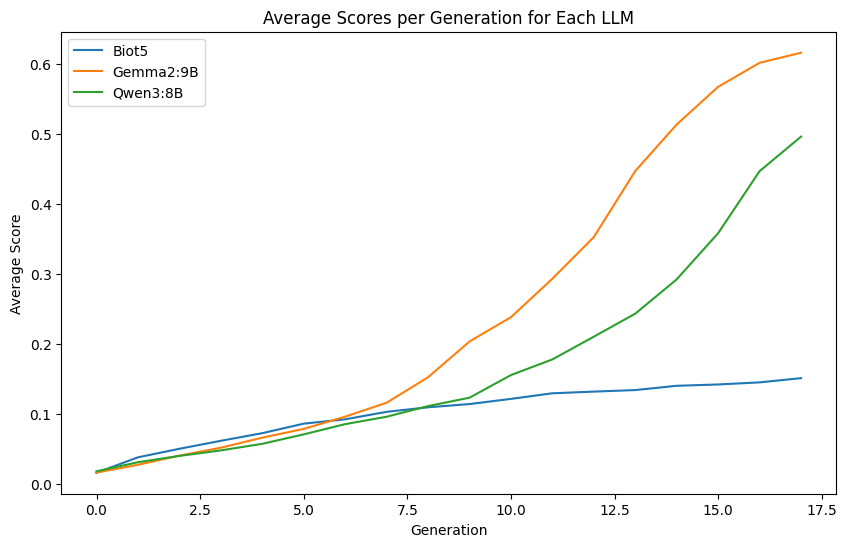

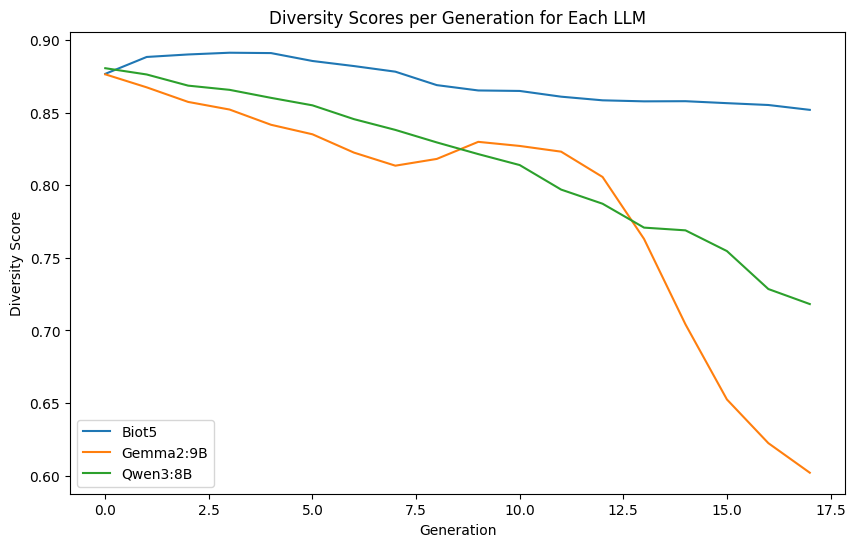

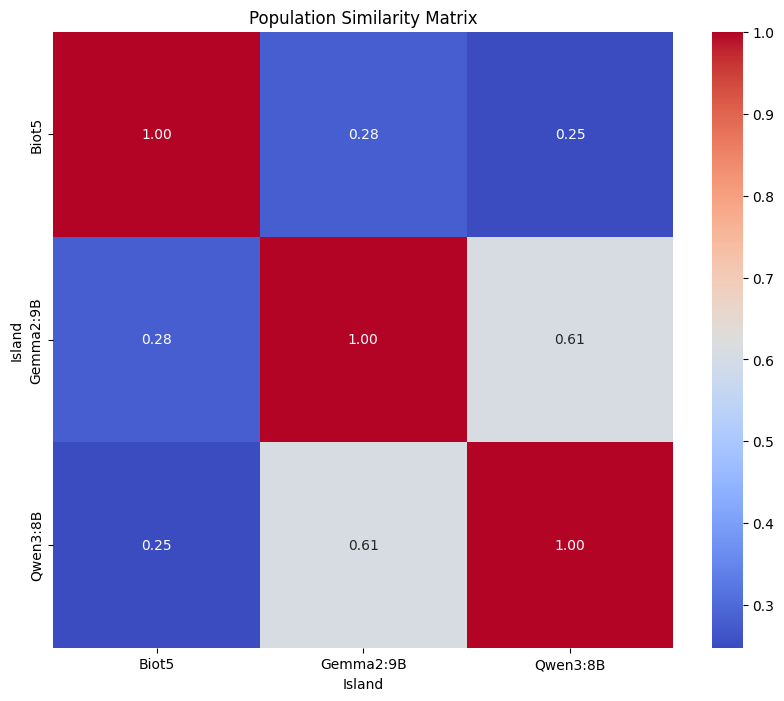

In [46]:
random1.plot_scoore_shift()
random1.plot_diversity_shift()
random1.plot_population_sim_matrix(generation=-1)

In [47]:
for population in random1.islands["Gemma2:9B"].populations:
    clustered_population = random1.cluster_population(population, cutoff=0.2)
    print(f"Number of clusters: {len(clustered_population)}, diversity: {random1.diversity_evaluator([mlc.smi for mlc in population])}")

Number of clusters: 100, diversity: 0.8763314427340729
Number of clusters: 96, diversity: 0.867363355064745
Number of clusters: 96, diversity: 0.8573325954578712
Number of clusters: 92, diversity: 0.8520860645759228
Number of clusters: 85, diversity: 0.841598171811643
Number of clusters: 83, diversity: 0.8350486996775318
Number of clusters: 78, diversity: 0.8224513538124918
Number of clusters: 80, diversity: 0.813443579875211
Number of clusters: 77, diversity: 0.8180967746249213
Number of clusters: 83, diversity: 0.8298474508555228
Number of clusters: 82, diversity: 0.8270297143007417
Number of clusters: 80, diversity: 0.8230939607757274
Number of clusters: 81, diversity: 0.805663345820044
Number of clusters: 81, diversity: 0.7630325809827736
Number of clusters: 80, diversity: 0.7042137100075307
Number of clusters: 83, diversity: 0.6525301860255306
Number of clusters: 79, diversity: 0.6224481325645158
Number of clusters: 80, diversity: 0.6020926072417091


Cluster 0: Size 5


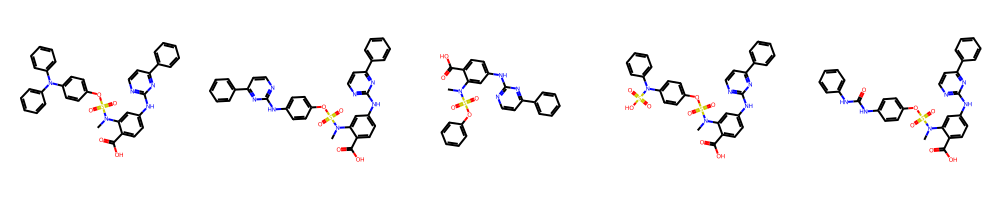

Cluster 1: Size 3


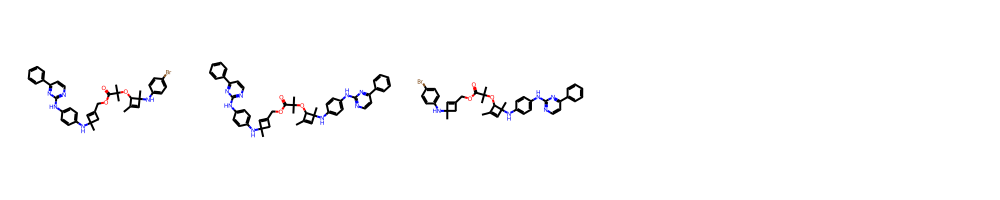

Cluster 2: Size 3


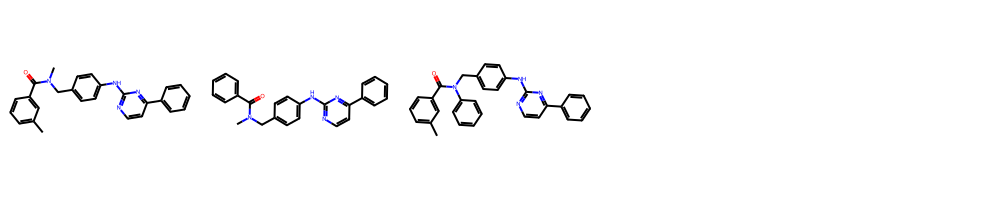

Cluster 3: Size 3


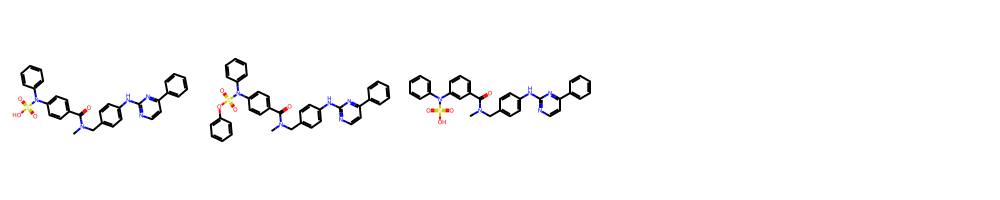

Cluster 4: Size 2


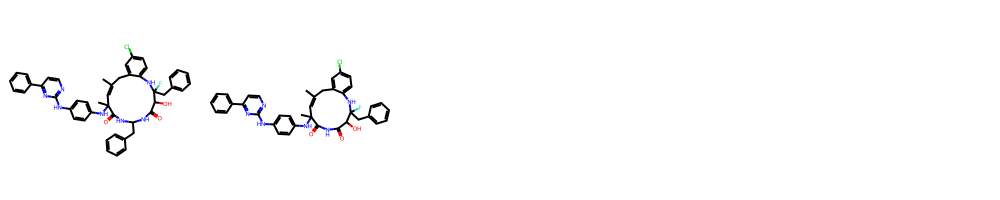

Cluster 5: Size 2


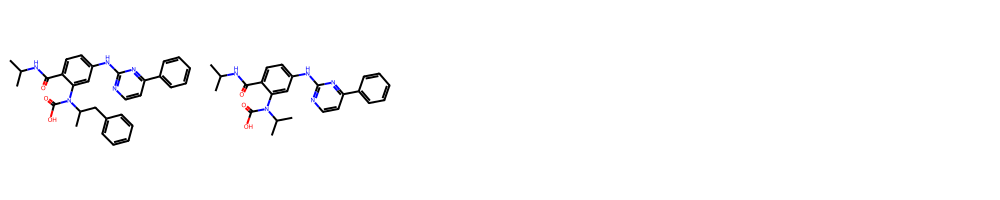

Cluster 6: Size 2


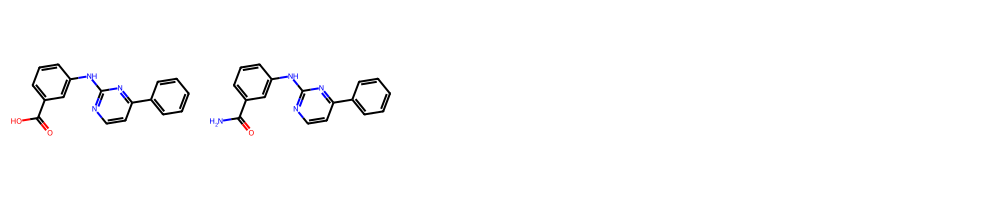

Cluster 7: Size 2


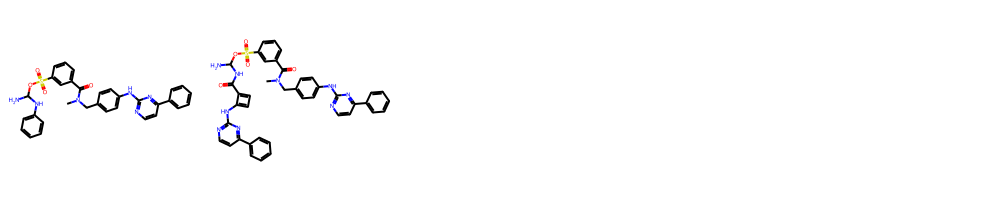

Cluster 8: Size 2


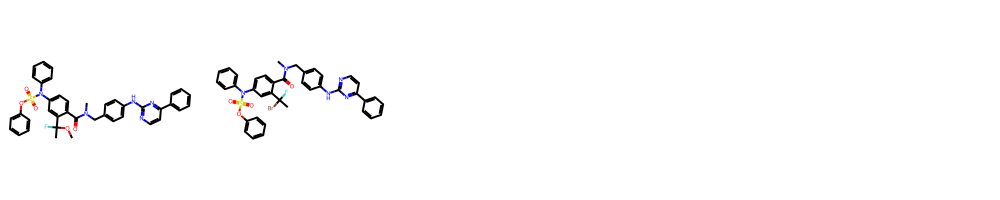

Cluster 9: Size 2


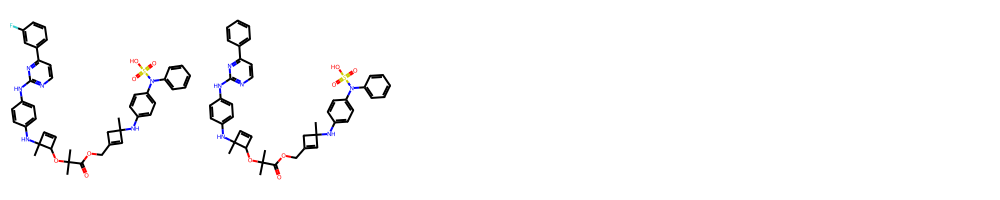

Cluster 10: Size 2


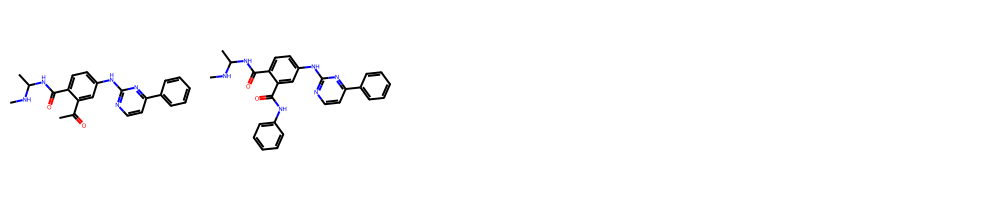

Cluster 11: Size 2


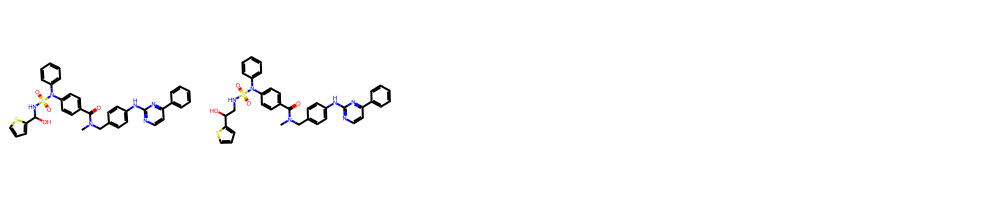

Cluster 12: Size 2


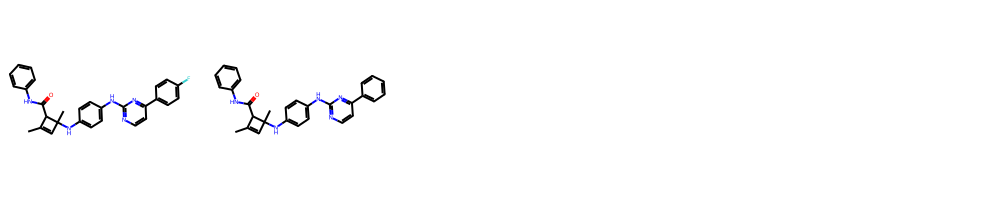

Cluster 13: Size 2


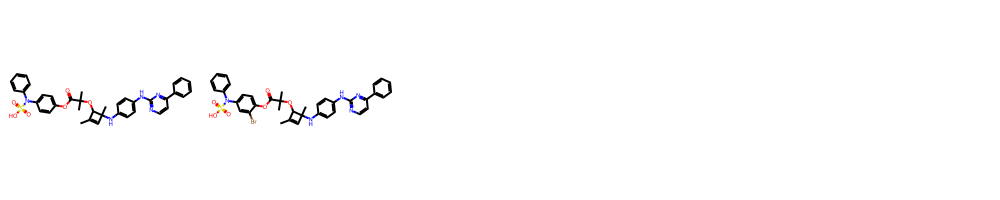

Cluster 14: Size 1


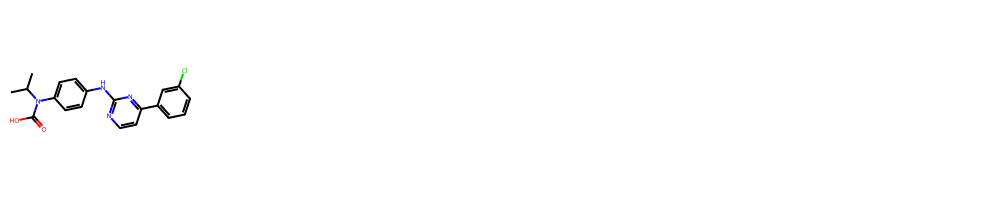

Cluster 15: Size 1


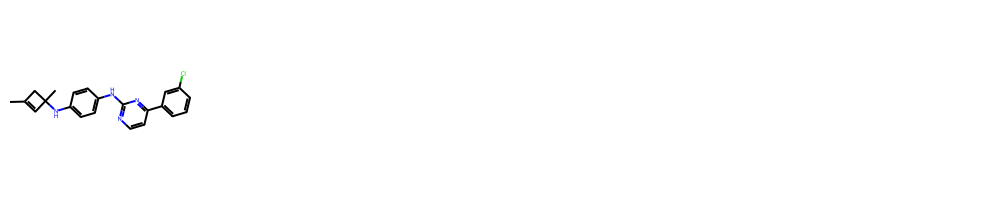

Cluster 16: Size 1


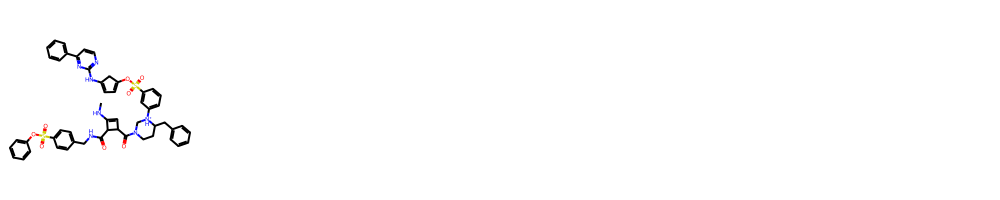

Cluster 17: Size 1


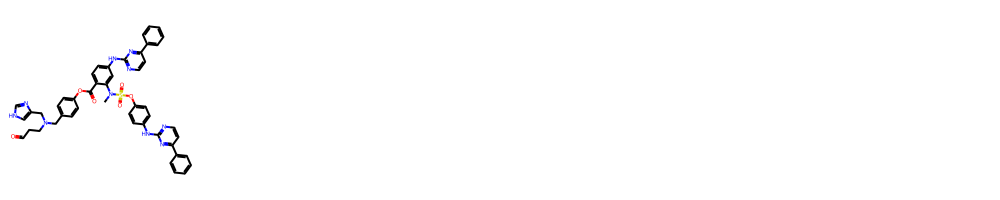

Cluster 18: Size 1


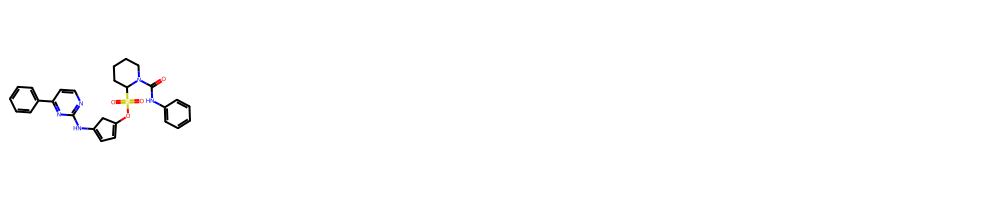

Cluster 19: Size 1


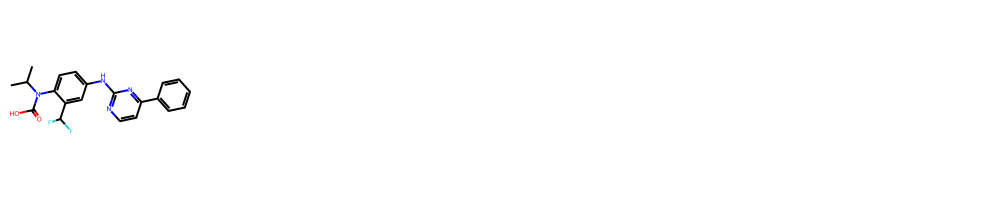

Cluster 20: Size 1


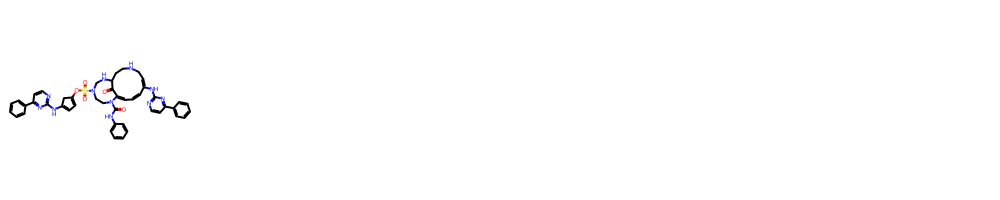

Cluster 21: Size 1


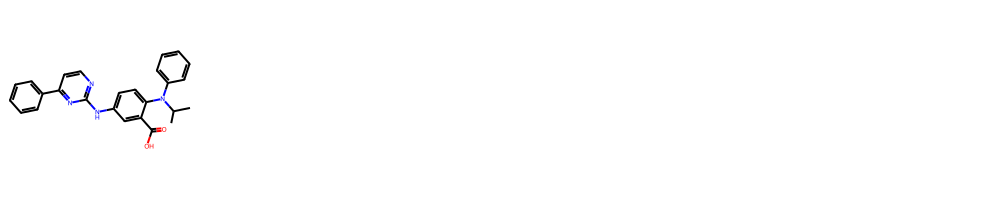

Cluster 22: Size 1


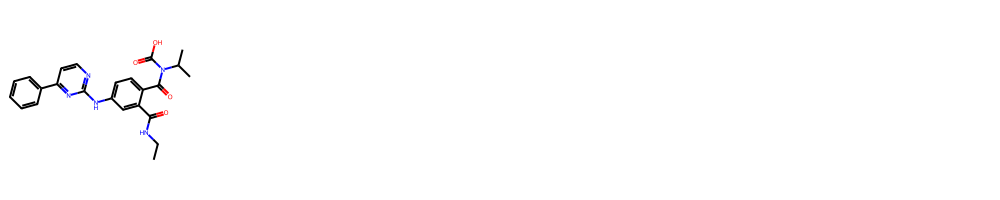

Cluster 23: Size 1


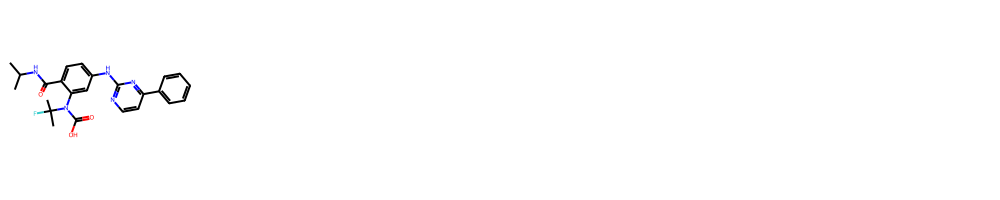

Cluster 24: Size 1


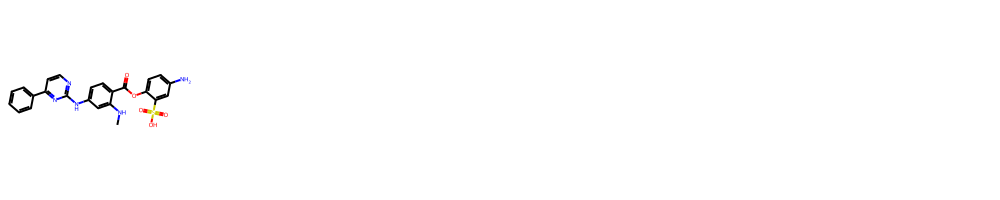

Cluster 25: Size 1


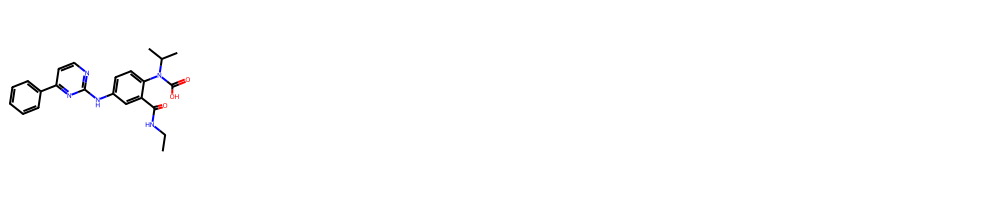

Cluster 26: Size 1


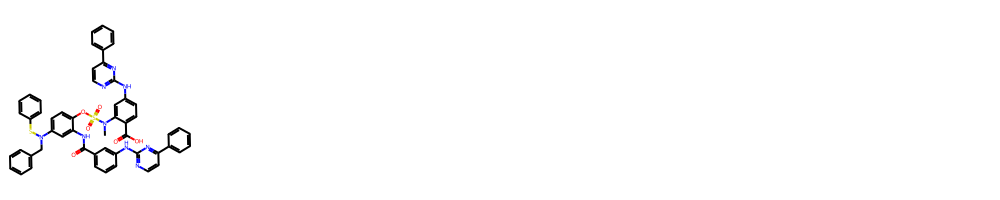

Cluster 27: Size 1


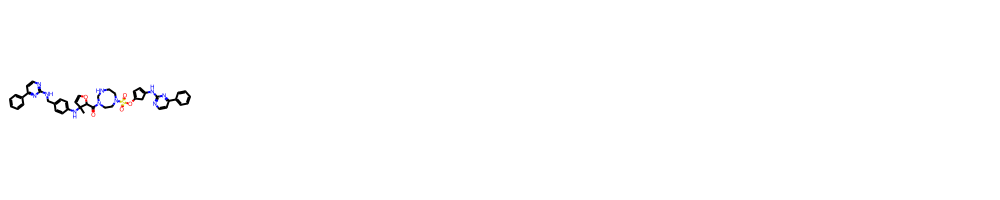

Cluster 28: Size 1


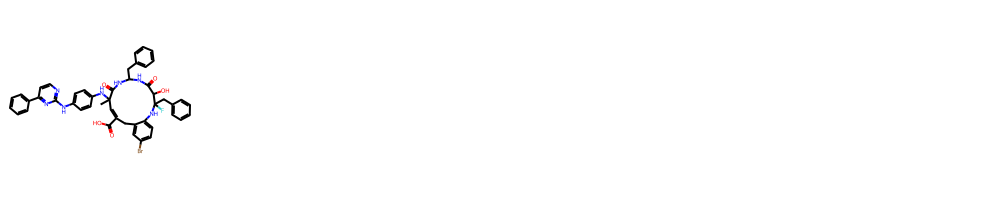

Cluster 29: Size 1


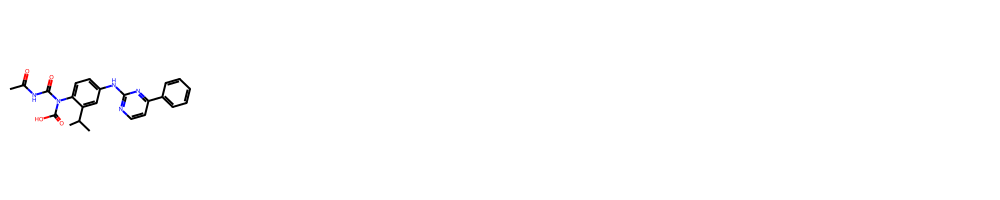

Cluster 30: Size 1


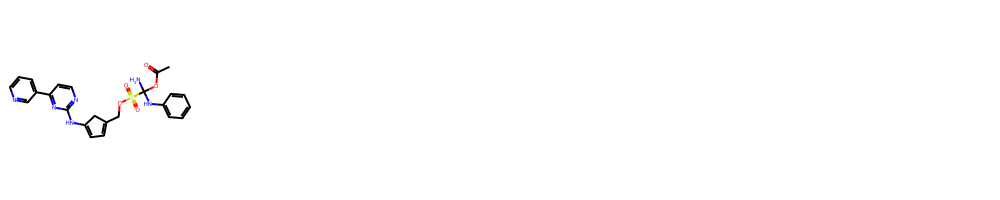

Cluster 31: Size 1


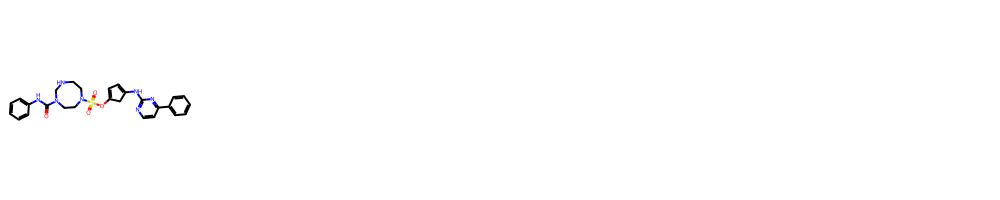

Cluster 32: Size 1


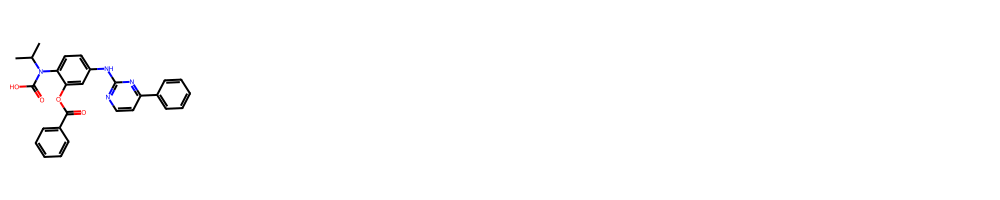

Cluster 33: Size 1


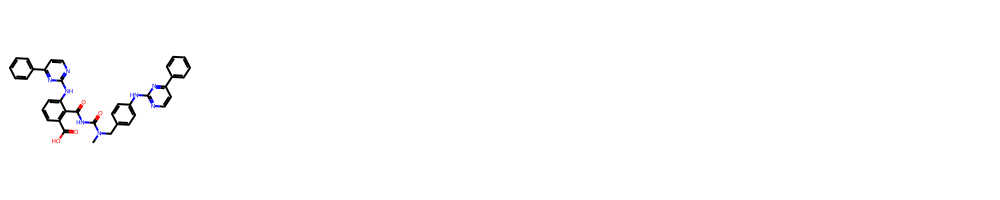

Cluster 34: Size 1


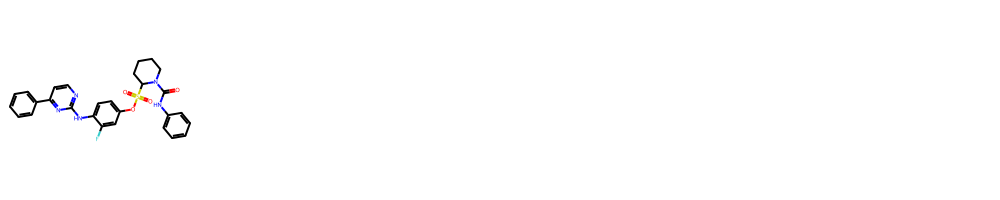

Cluster 35: Size 1


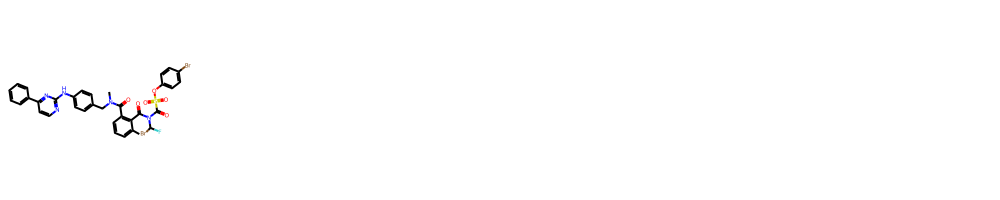

Cluster 36: Size 1


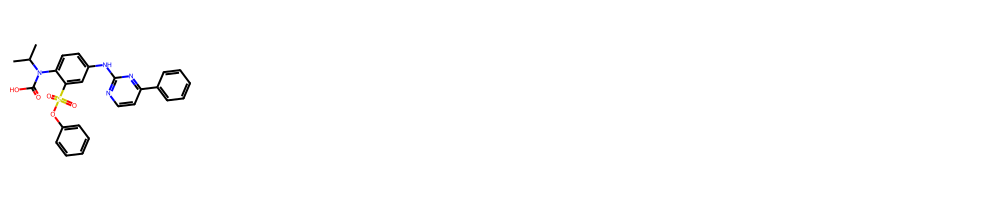

Cluster 37: Size 1


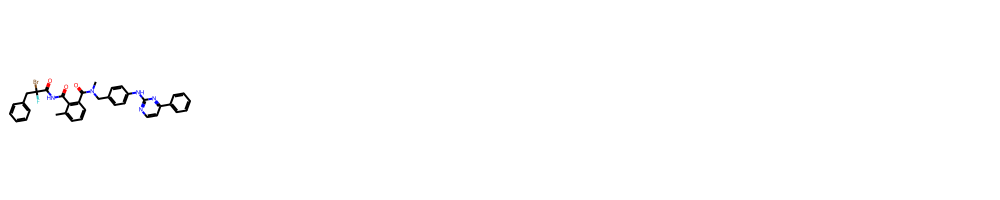

Cluster 38: Size 1


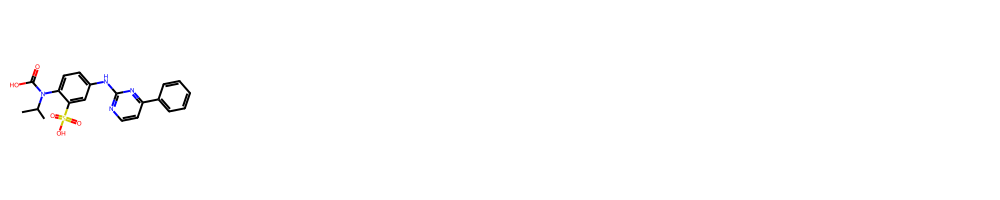

Cluster 39: Size 1


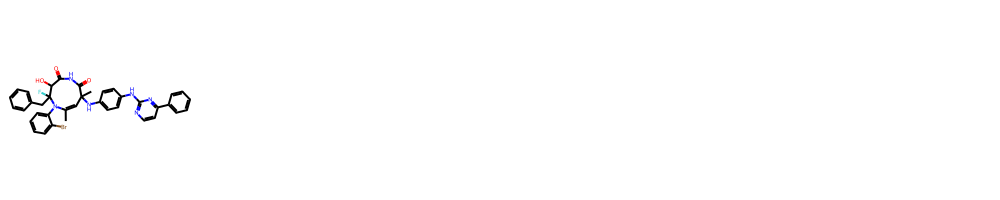

Cluster 40: Size 1


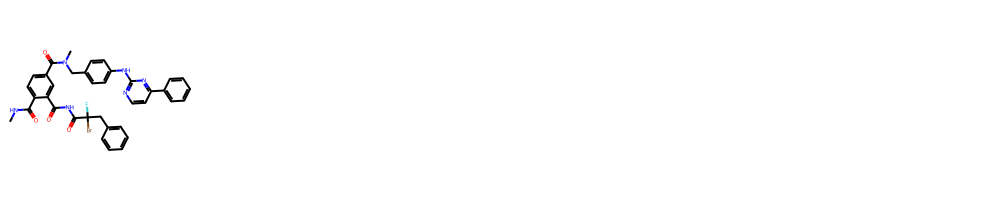

Cluster 41: Size 1


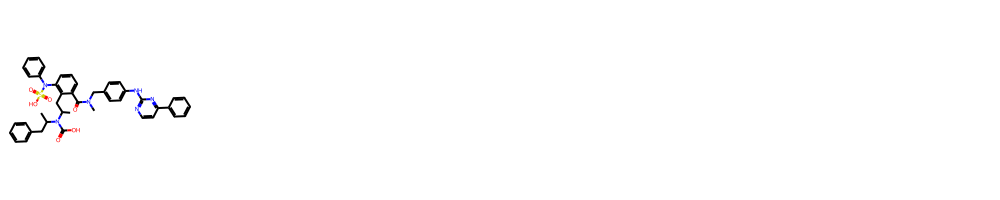

Cluster 42: Size 1


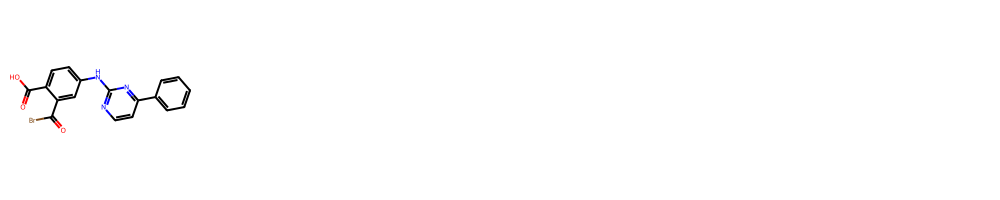

Cluster 43: Size 1


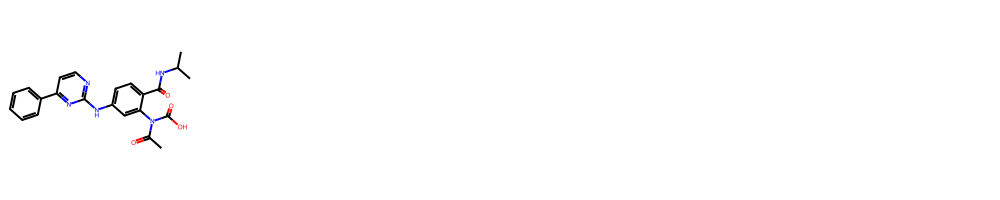

Cluster 44: Size 1


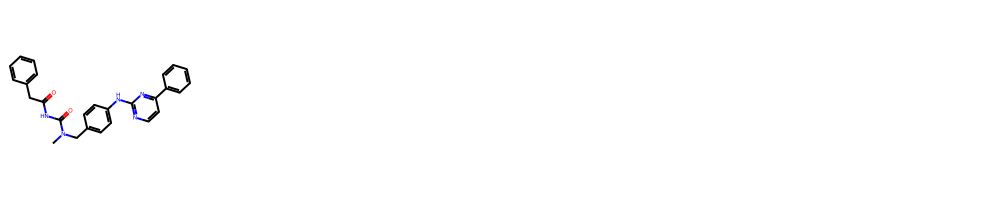

Cluster 45: Size 1


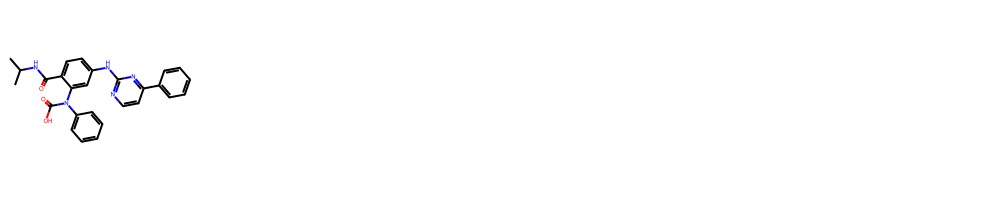

Cluster 46: Size 1


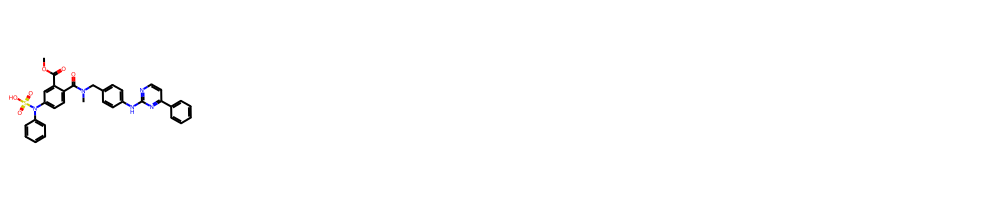

Cluster 47: Size 1


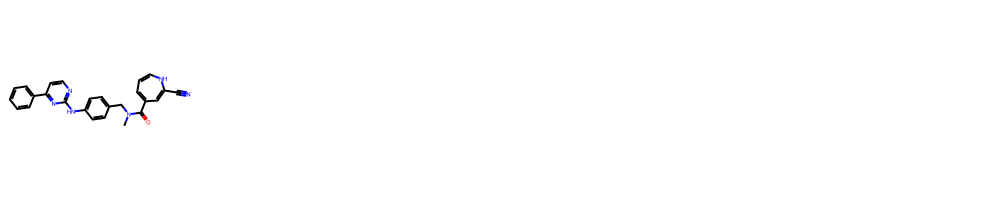

Cluster 48: Size 1


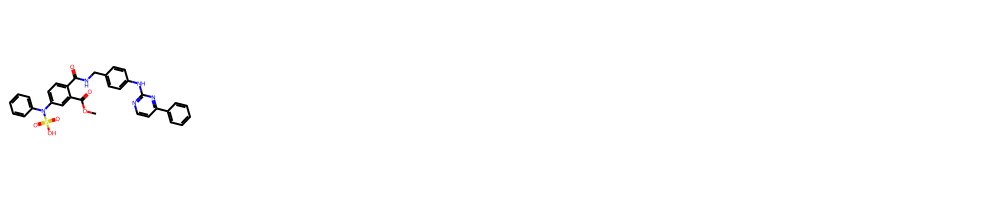

Cluster 49: Size 1


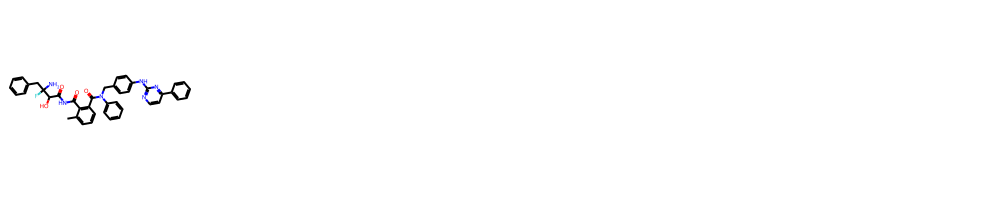

Cluster 50: Size 1


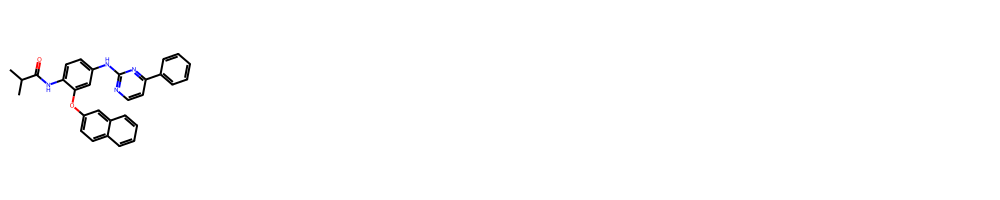

Cluster 51: Size 1


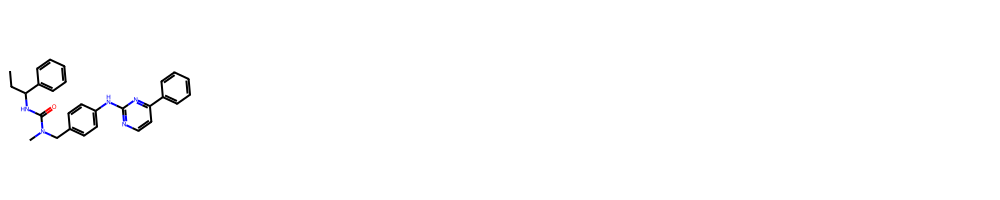

Cluster 52: Size 1


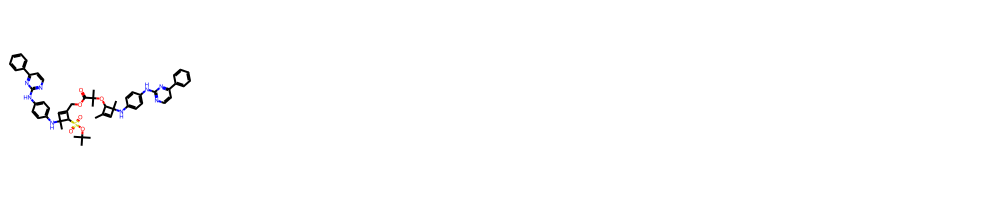

Cluster 53: Size 1


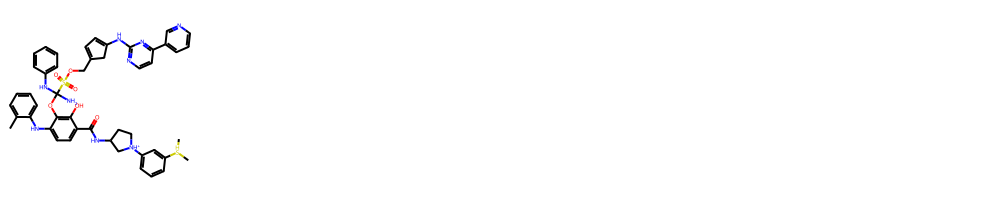

Cluster 54: Size 1


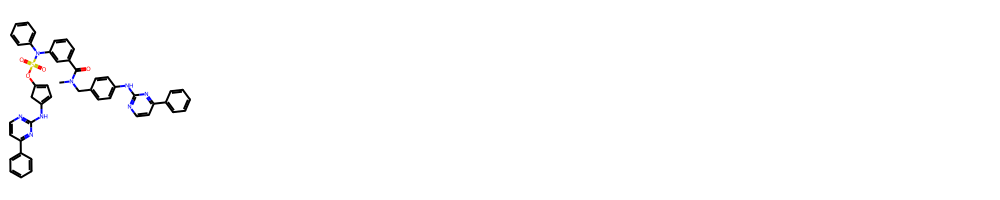

Cluster 55: Size 1


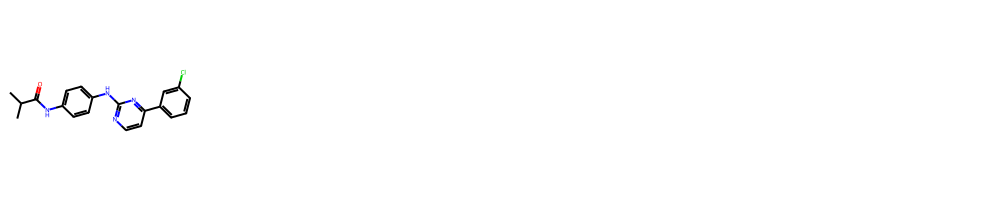

Cluster 56: Size 1


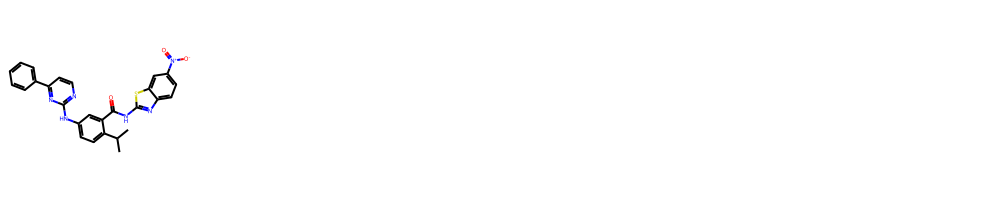

Cluster 57: Size 1


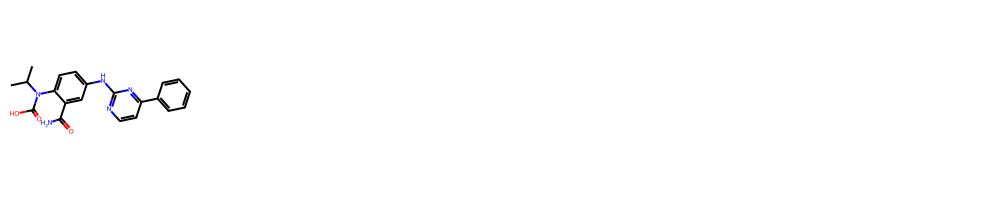

Cluster 58: Size 1


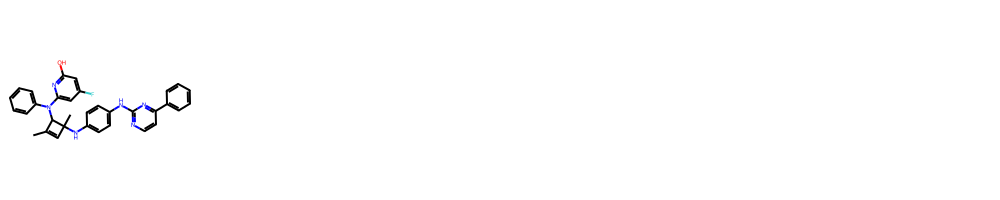

Cluster 59: Size 1


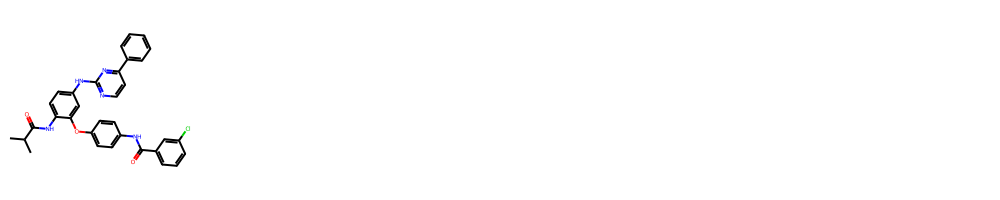

Cluster 60: Size 1


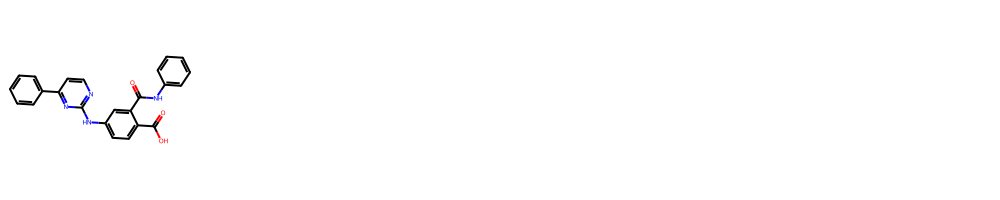

Cluster 61: Size 1


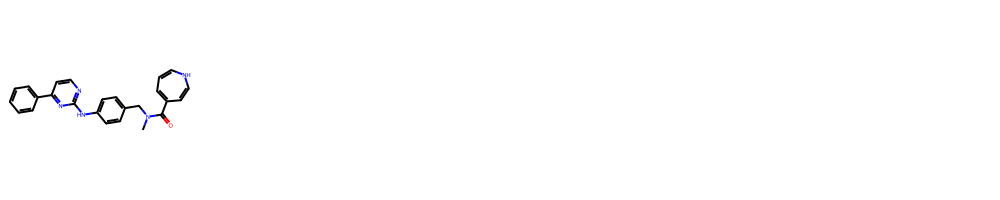

Cluster 62: Size 1


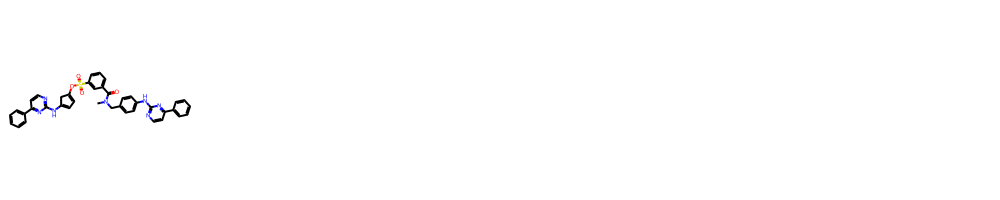

Cluster 63: Size 1


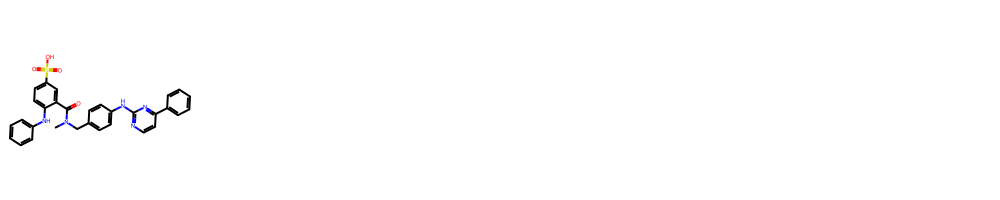

Cluster 64: Size 1


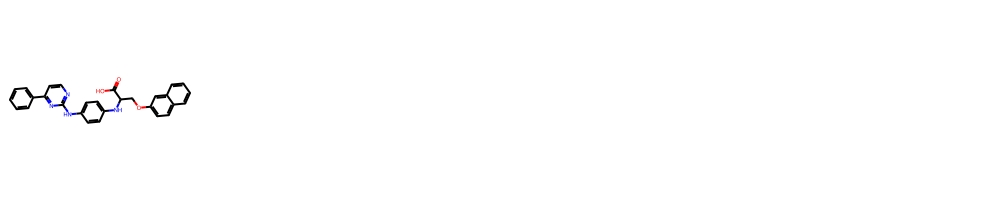

Cluster 65: Size 1


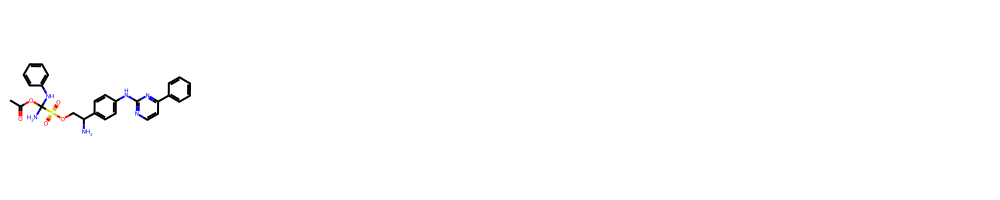

Cluster 66: Size 1


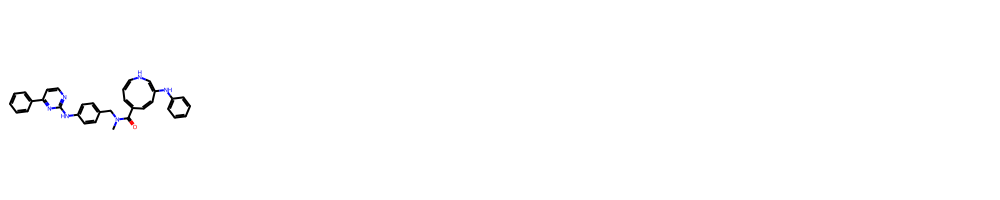

Cluster 67: Size 1


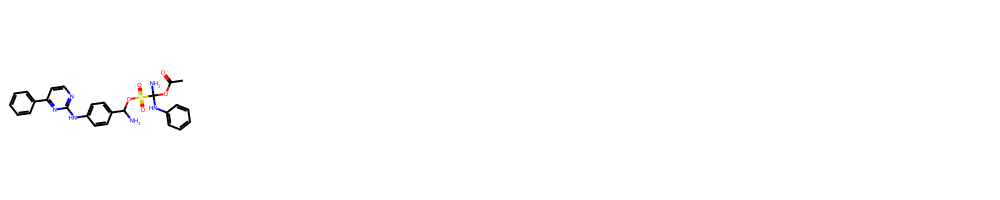

Cluster 68: Size 1


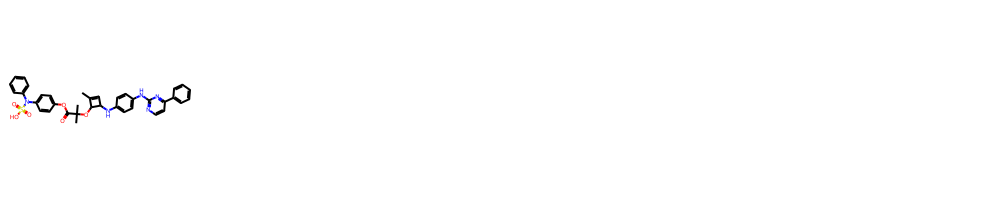

Cluster 69: Size 1


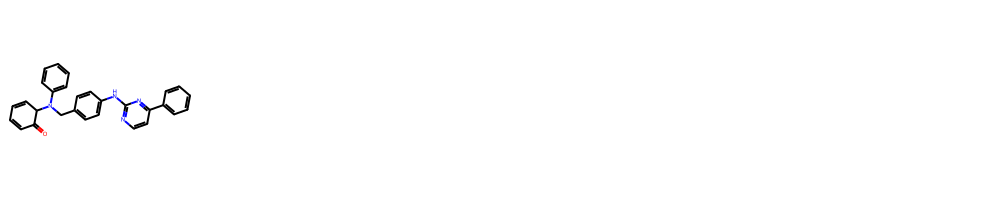

Cluster 70: Size 1


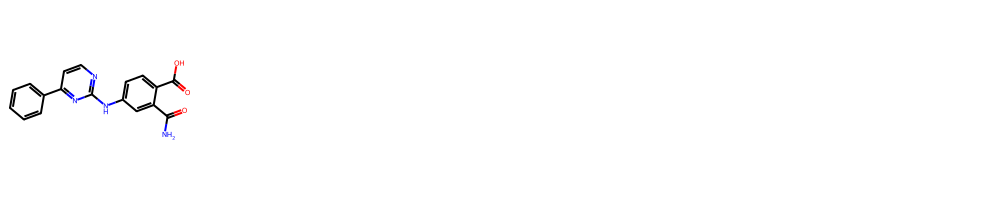

Cluster 71: Size 1


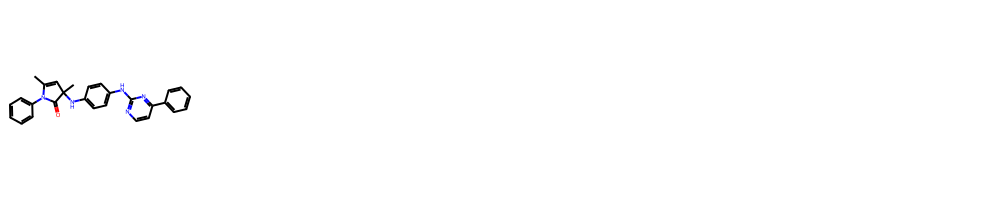

Cluster 72: Size 1


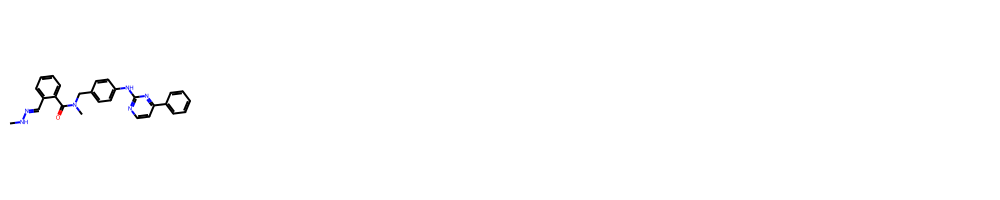

Cluster 73: Size 1


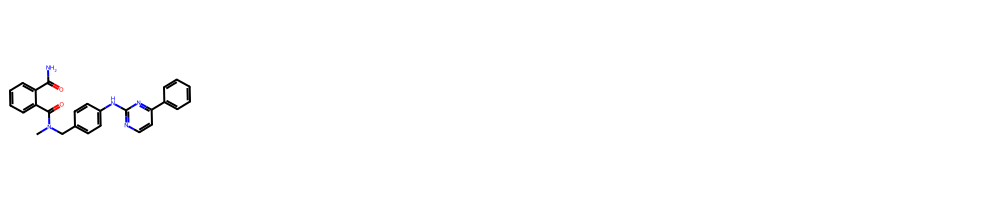

Cluster 74: Size 1


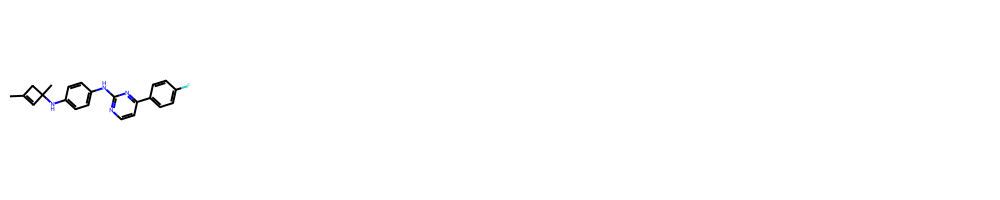

Cluster 75: Size 1


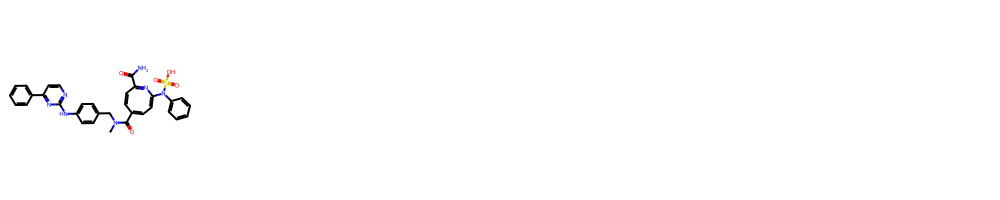

Cluster 76: Size 1


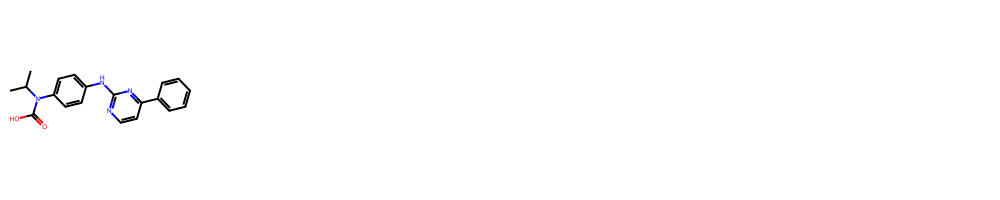

Cluster 77: Size 1


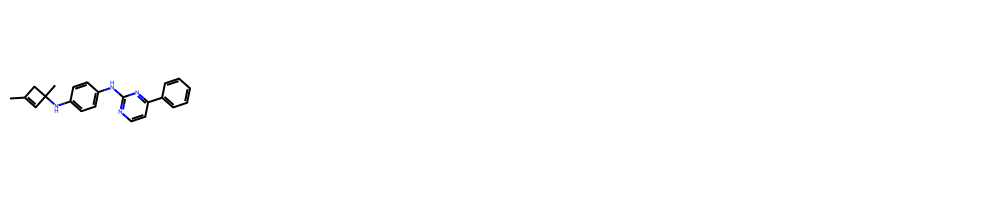

Cluster 78: Size 1


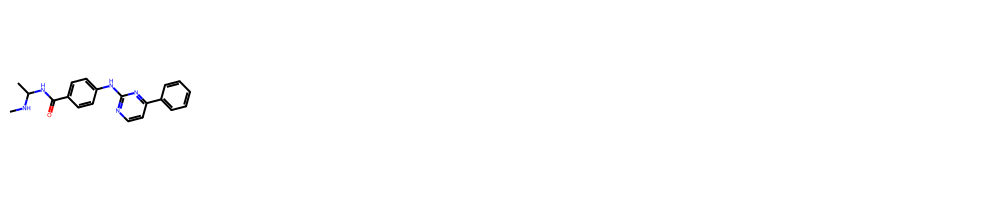

Cluster 79: Size 1


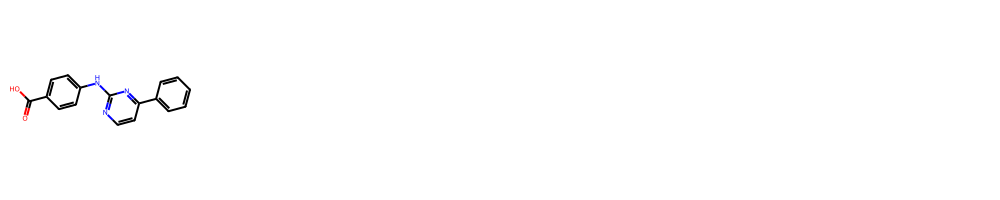

In [54]:
last_cluster = random1.cluster_population(random1.islands["Gemma2:9B"].populations[-1],cutoff=0.2)
for i, cluster in enumerate(last_cluster):
    print(f"Cluster {i}: Size {len(cluster)}")
    random1.draw_molecules(cluster,num=5)

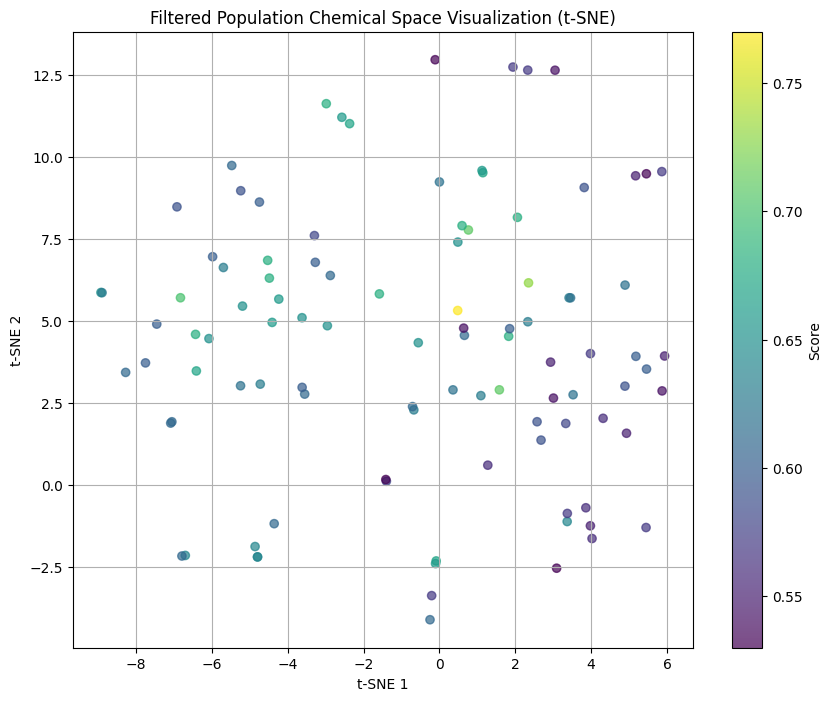

In [49]:
random1.plot_population_fingerprints(random1.islands["Gemma2:9B"].populations[-1], title="Filtered Population Chemical Space Visualization (t-SNE)")